## They ask me to refactor things. 

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import string
import re

from collections import Counter
import plotly.express as px

import nltk
from nltk.corpus import stopwords


In [6]:
df = pd.read_csv('../data/tokopedia_product_reviews_2025.csv')

## Raw Review
1. no duplicate reviews
2. due too many dataset --> reduce the positive sentiment
3. then we get 92.6% of positive sentiment
4. mostly are makanan&minuman, and olahraga --- tho it's still useless for now. 
5. 

In [7]:
# for nice plotting
def without_hue(plot, feature, yp=20):
    total = len(feature)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.08
        y = p.get_y() + p.get_height() + yp
        ax.annotate(percentage, (x, y), size = 10)
    plt.show()

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


<class 'pandas.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   review_text       65543 non-null  str           
 1   review_date       65543 non-null  datetime64[us]
 2   review_id         65543 non-null  int64         
 3   product_name      65543 non-null  str           
 4   product_category  65543 non-null  str           
 5   product_variant   26749 non-null  str           
 6   product_price     65543 non-null  int64         
 7   product_url       65543 non-null  str           
 8   product_id        65543 non-null  int64         
 9   rating            65543 non-null  int64         
 10  sold_count        65543 non-null  int64         
 11  shop_id           65543 non-null  int64         
 12  sentiment_label   65543 non-null  str           
dtypes: datetime64[us](1), int64(6), str(6)
memory usage: 25.6 MB
0
7380


C:\Users\ACER\AppData\Local\Temp\ipykernel_16788\191919597.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="sentiment_label", data=df, palette="muted")


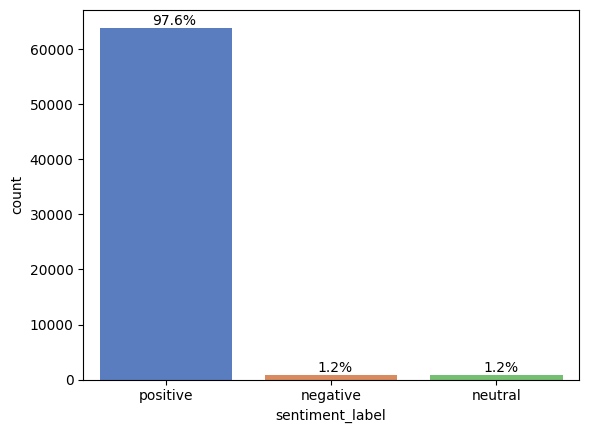

In [8]:
df['review_date'] = pd.to_datetime(df.review_date)
display(df.head())
df.info()

df["raw_length"] = df.review_text.apply(lambda x: len(x.split()))

# no duplicate entries. 
print(df.duplicated().sum())

# but duplicates review text & rating 7380 around 10% using the same review
print(df[['review_text', 'rating']].duplicated().sum())

ax = sns.countplot(x="sentiment_label", data=df, palette="muted")
without_hue(ax, df.sentiment_label, yp=500)


C:\Users\ACER\AppData\Local\Temp\ipykernel_16788\1416717516.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="sentiment_label", data=df, palette="muted")


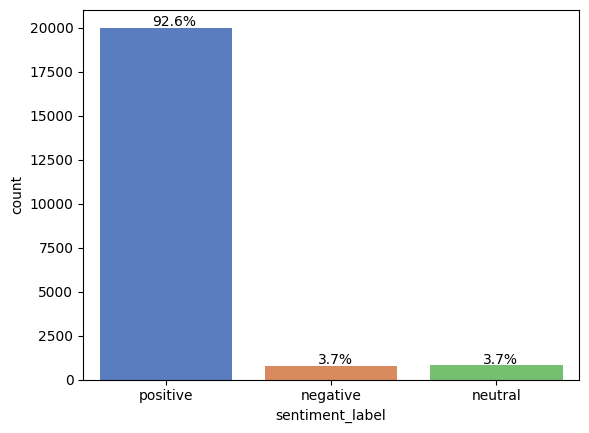

In [9]:
# due to too much data, reduce. hehe. 

df01 = df[df.sentiment_label=="positive"].sample(n=20000, random_state=1, replace=False)
df = pd.concat([df01, df[df.sentiment_label != "positive"]])

ax = sns.countplot(x="sentiment_label", data=df, palette="muted")
without_hue(ax, df.sentiment_label, yp=100)


review_text             0
review_date             0
review_id               0
product_name            0
product_category        0
product_variant     12797
product_price           0
product_url             0
product_id              0
rating                  0
sold_count              0
shop_id                 0
sentiment_label         0
raw_length              0
dtype: int64


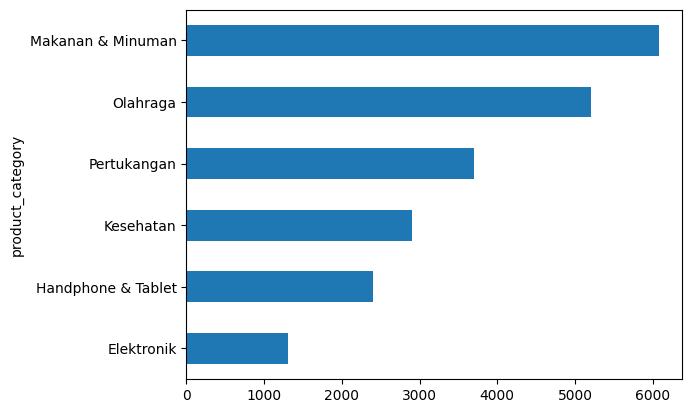

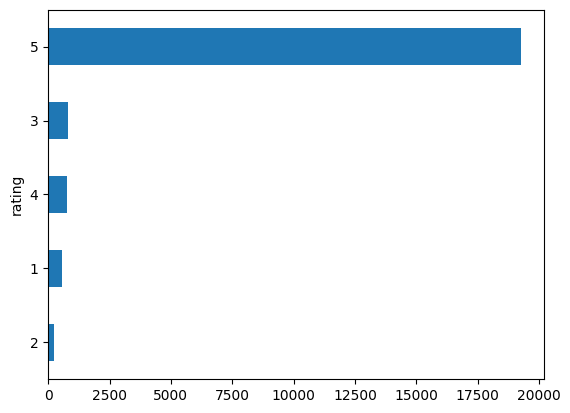

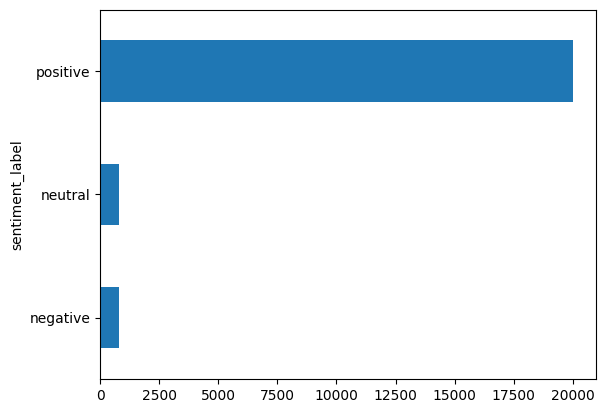

In [10]:
# missing in product variant -- not useful 
print(df.isna().sum())

# sns.coutnplot
for i in "product_category rating sentiment_label".split():
    df[i].value_counts(ascending=True).plot(kind="barh")
    plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_16788\2887166242.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="sentiment_label", data=df, palette="muted")


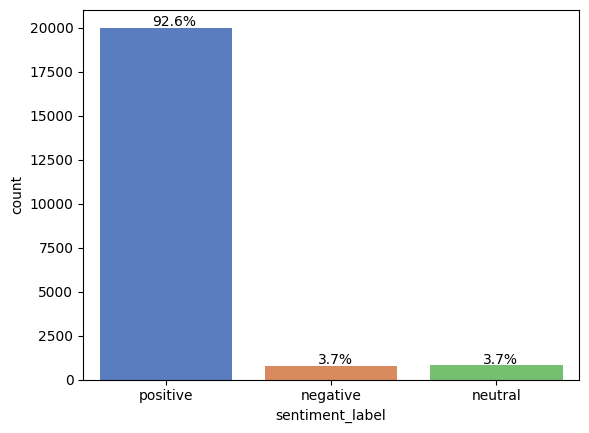

C:\Users\ACER\AppData\Local\Temp\ipykernel_16788\2887166242.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="rating", data=df, palette="muted")


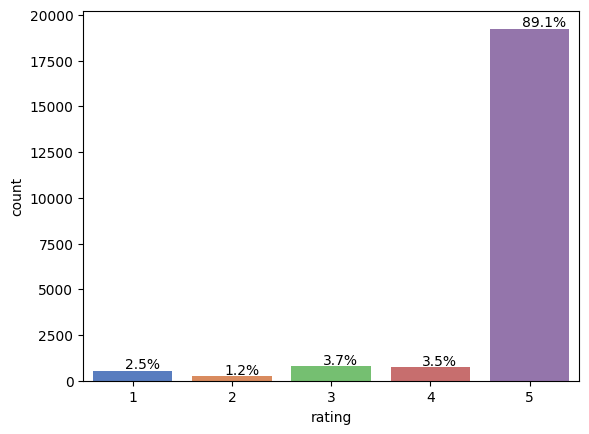

In [11]:
ax = sns.countplot(x="sentiment_label", data=df, palette="muted")
without_hue(ax, df.sentiment_label, yp=100)

ax = sns.countplot(x="rating", data=df, palette="muted")
without_hue(ax, df.rating, yp=100)

In [12]:
df.describe()

,review_date,review_id,product_price,product_id,rating,sold_count,shop_id,raw_length
count,21600,2.160000e+04,2.160000e+04,2.160000e+04,21600.000000,21600.000000,2.160000e+04,21600.000000
mean,2023-08-22 22:39:32,9.783934e+08,5.185103e+05,2.444080e+10,4.754722,1905.817454,9.299059e+16,12.030648
min,2016-02-25 00:00:00,1.444468e+07,1.000000e+02,4.298375e+06,1.000000,6.000000,6.050000e+02,1.000000
25%,2022-07-16 00:00:00,7.144898e+08,2.900000e+04,1.417715e+09,5.000000,100.000000,2.298522e+06,5.000000
50%,2023-11-25 00:00:00,9.717652e+08,7.950000e+04,4.632178e+09,5.000000,500.000000,5.786979e+06,9.000000
75%,2024-12-17 00:00:00,1.145109e+09,2.085000e+05,1.533803e+10,5.000000,1000.000000,9.015158e+06,15.000000
max,2025-12-11 00:00:00,1.809382e+09,9.999900e+07,1.026778e+11,5.000000,1000000.000000,7.496220e+18,446.000000
std,NaN,4.192766e+08,2.266960e+06,3.873042e+10,0.795623,14700.327770,8.296549e+17,12.642978


## Text Cleaning
1. to text and lowercase
3. remove links 4. remove html tags 5. remove punctuation 
6. remove newlines 7. remove words containing numbers 
7. remove single characters 8. remove extra spaces
5. no lemmatization since it took too long
6. no stopwords removal since some of them actually important (i guess)
7. for cleaned words, length mostly (99 percent) below 60, with median just around 9.

In [13]:
def clean_text(text):
    '''
    1. to text and lowercase 2. strip out text inside brackets 
    3. remove links 4. remove html tags 5. remove punctuation 
    6. remove newlines 7. remove words containing numbers 
    8. remove single characters 9. remove extra spaces
    '''
    text = str(text).lower()
    # text = re.sub('.∗?.*?', '', text)
    text = re.sub('https?://\S+|www\.\S+', ' ', text)
    text = re.sub('<.*?>+', ' ', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('\w*\d\w*', ' ', text)
    text = re.sub(r"\b[a-zA-Z]\b", " ", text) #rm single char
    text = re.sub(" +", " ", text.strip()) 
    
    return text

# let's ignore stopwords and lemmatization. just simple text cleaning will do, okay? 

In [14]:
# should we do lemmatization
df["clean_text"] = df['review_text'].apply(lambda x:clean_text(x))
df["clean_length"] = df.clean_text.apply(lambda x: len(x.split()))

# remove stopwords. 
df.describe()

,review_date,review_id,product_price,product_id,rating,sold_count,shop_id,raw_length,clean_length
count,21600,2.160000e+04,2.160000e+04,2.160000e+04,21600.000000,21600.000000,2.160000e+04,21600.000000,21600.000000
mean,2023-08-22 22:39:32,9.783934e+08,5.185103e+05,2.444080e+10,4.754722,1905.817454,9.299059e+16,12.030648,11.877361
min,2016-02-25 00:00:00,1.444468e+07,1.000000e+02,4.298375e+06,1.000000,6.000000,6.050000e+02,1.000000,0.000000
25%,2022-07-16 00:00:00,7.144898e+08,2.900000e+04,1.417715e+09,5.000000,100.000000,2.298522e+06,5.000000,5.000000
50%,2023-11-25 00:00:00,9.717652e+08,7.950000e+04,4.632178e+09,5.000000,500.000000,5.786979e+06,9.000000,9.000000
75%,2024-12-17 00:00:00,1.145109e+09,2.085000e+05,1.533803e+10,5.000000,1000.000000,9.015158e+06,15.000000,15.000000
max,2025-12-11 00:00:00,1.809382e+09,9.999900e+07,1.026778e+11,5.000000,1000000.000000,7.496220e+18,446.000000,447.000000
std,NaN,4.192766e+08,2.266960e+06,3.873042e+10,0.795623,14700.327770,8.296549e+17,12.642978,12.318557


count    21390.000000
mean        11.136653
std          9.000318
min          0.000000
25%          5.000000
50%          9.000000
75%         14.000000
max         59.000000
Name: clean_length, dtype: float64

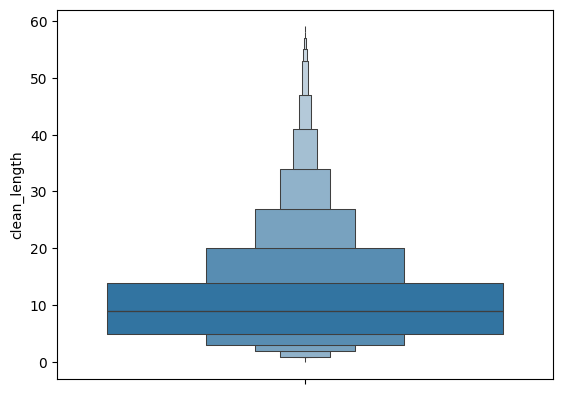

In [15]:
# 99 percent of the data is here. 
sns.boxenplot(df.clean_length[df.clean_length<=df.clean_length.quantile(0.99)])

df.clean_length[df.clean_length<=df.clean_length.quantile(0.99)].describe()

## More EDA tho Fail in Local
1. positive: cepat, sesuai, bagus, aman, baik
2. negative: 

In [16]:
# Counter
def commonWords(label="positive negative neutral".split(), text_col="clean_text"):
    top = Counter([item for sublist in df.loc[df.sentiment_label.isin(label),text_col].str.split() for item in sublist])
    temp = pd.DataFrame(top.most_common(20))
    temp.columns = ['Common_words','count']
    temp.head()
    
    fig = px.treemap(temp, path=['Common_words'], values='count',title=f'20 Most Common Words in {label}')
    fig.show()

from nltk.tokenize import word_tokenize

def freqWords(data=df, label="positive negative neutral".split(), text_col="clean_text"):
    all_words = " ".join(data.loc[data.sentiment_label.isin(label),text_col]).split()
    fqdist = nltk.probability.FreqDist(all_words)
    print(fqdist.most_common(15))

    plt.figure()
    fig = fqdist.plot(10, cumulative=False)
    fig.set_title(f'10 Most Common Words in {label}')
    plt.show()
    

# all_words = " ".join(df.clean_text).split()
# fqdist = nltk.probability.FreqDist(all_words)
# print(fqdist.most_common(15))
# fqdist.plot(10,cumulative=False)


[('dan', 6836), ('cepat', 5145), ('sesuai', 5138), ('barang', 4834), ('bagus', 4568), ('pengiriman', 3564), ('seller', 2740), ('aman', 2570), ('dengan', 2525), ('baik', 2511), ('di', 2316), ('nya', 2119), ('packing', 2089), ('produk', 1976), ('pesanan', 1873)]


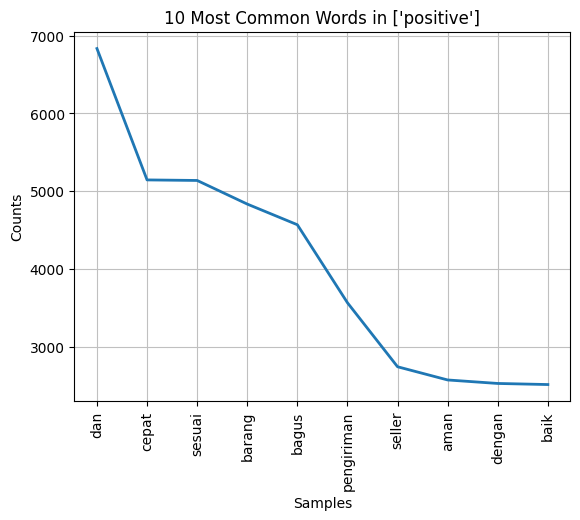

[('di', 385), ('tidak', 350), ('dan', 294), ('yg', 267), ('barang', 259), ('saya', 256), ('ada', 213), ('nya', 189), ('yang', 180), ('ini', 177), ('sudah', 159), ('beli', 153), ('ga', 142), ('bisa', 134), ('dikirim', 124)]


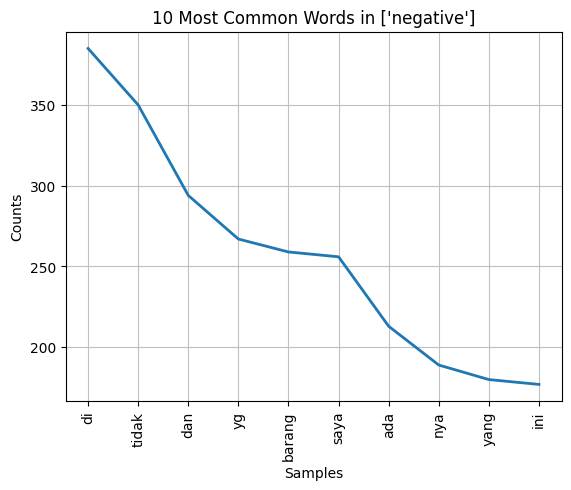

[('yg', 255), ('dan', 225), ('di', 225), ('ada', 211), ('nya', 191), ('tidak', 185), ('saya', 160), ('kurang', 151), ('barang', 151), ('tapi', 129), ('ini', 125), ('yang', 112), ('bagus', 111), ('bisa', 104), ('sudah', 100)]


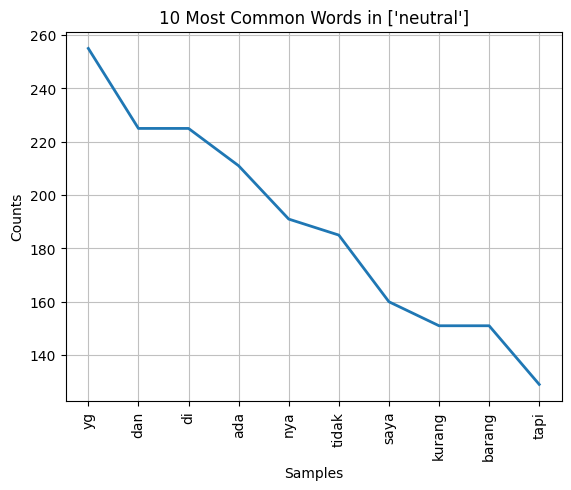

In [17]:
# commonWords()
for i in df.sentiment_label.unique():
    freqWords(label=[i])

## More Cleaning
1. drop 0 word
2. normalized from slang words

More eda, most common words
1. positive: dan, cepat, sesuai, barang, bagus, pengiriman
2. negative: yang, tidak, di, enggak , sudah, dan, saya
3. neutral: yang, dan, di, tidak, ada, tapi, enggak

In [18]:
# drop 0 word 
df1 = df.loc[df.clean_length>0, 
"review_text clean_text sentiment_label review_date clean_length".split()].copy()

In [19]:
# normalized
norm_word = pd.read_csv("../data/colloquial-indonesian-lexicon.csv")
norm_word_dict = {}

for index, row in norm_word.iterrows():
    if row["slang"] not in norm_word_dict:
        norm_word_dict[row["slang"]] = row["formal"]
 
norm_word_dict["brg"] = "barang"
norm_word_dict["mantab"] = "mantap"

In [20]:
def normalized_term(document):
    return [norm_word_dict[term] if term in norm_word_dict else term for term in document]

# stopwords
nltk.download('stopwords')
list_stopwords = stopwords.words('indonesian')

def stopwords_removal(words):
    return [word for word in words if word not in list_stopwords]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
df1["tokenized"] = df1.clean_text.str.split()

# stemming (too slow will skip) --> normalization (if needed) --> stopwords 
# stemmer = StemmerFactory().create_stemmer()
# df1["clean_text"] = df1.clean_text.swifter.apply(stemmer.stem)

# normalized.  
df1['tokenized'] = df1['tokenized'].apply(normalized_term)
df1['clean_text'] = df1.tokenized.apply(lambda x: " ".join(x))

# stopwords, but let skip this as well.  
# df1['tokenized'] = df1['tokenized'].apply(stopwords_removal)

[('mantap', 219), ('bagus', 206), ('good', 71), ('sesuai pesanan', 51), ('terima kasih', 43), ('sesuai', 36), ('barang sesuai deskripsi', 33), ('barang sesuai pesanan', 26), ('pengiriman cepat', 25), ('keren', 22), ('barang bagus', 22), ('sesuai deskripsi', 19), ('nice', 19), ('terimakasih', 17), ('mantul', 16)]
[('dan', 6851), ('cepat', 5716), ('sesuai', 5138), ('barang', 4970), ('bagus', 4766), ('pengiriman', 3564), ('dengan', 3221), ('sudah', 2866), ('seller', 2740), ('aman', 2570), ('baik', 2516), ('yang', 2513), ('terima', 2419), ('di', 2323), ('banget', 2306)]


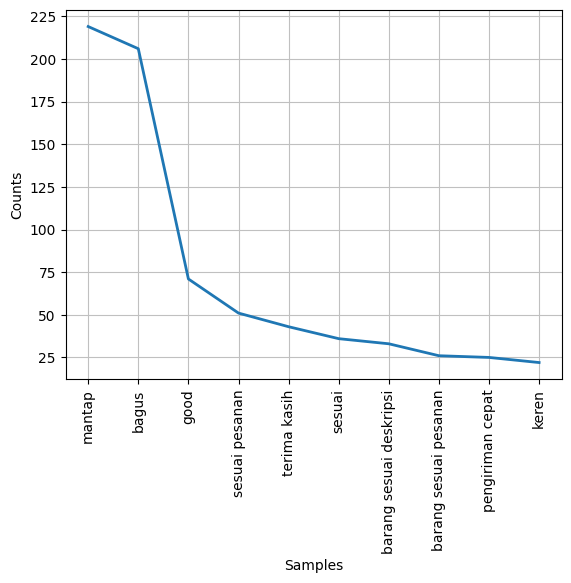

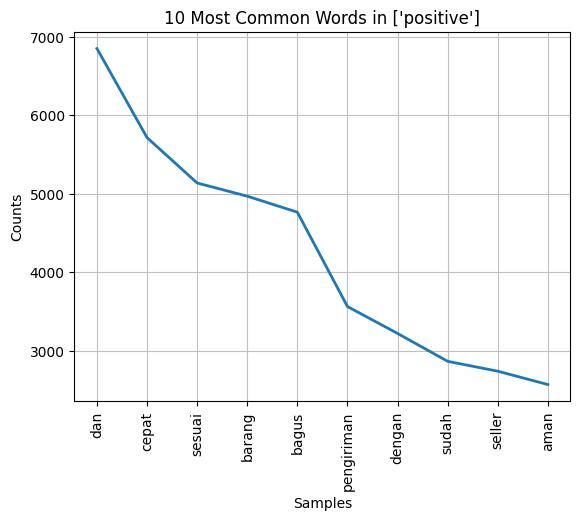

[('yang', 447), ('tidak', 417), ('di', 388), ('enggak', 335), ('sudah', 300), ('dan', 294), ('saya', 282), ('barang', 273), ('ada', 222), ('nya', 197), ('tapi', 192), ('ini', 183), ('beli', 154), ('bisa', 146), ('dikirim', 124)]


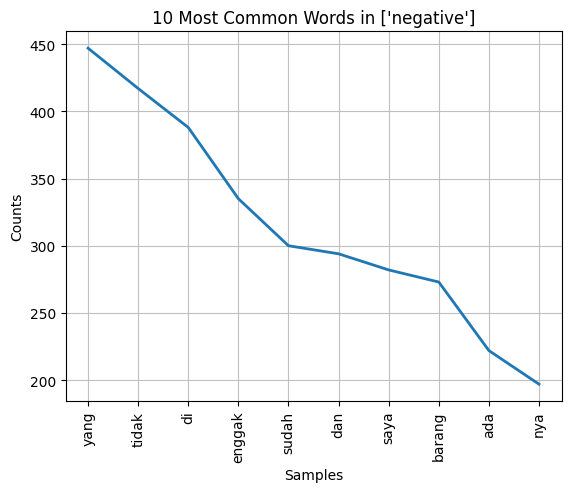

[('yang', 367), ('dan', 225), ('di', 225), ('tidak', 222), ('ada', 219), ('tapi', 211), ('enggak', 204), ('nya', 199), ('sudah', 184), ('saya', 177), ('barang', 159), ('kurang', 151), ('ini', 132), ('bisa', 118), ('bagus', 117)]


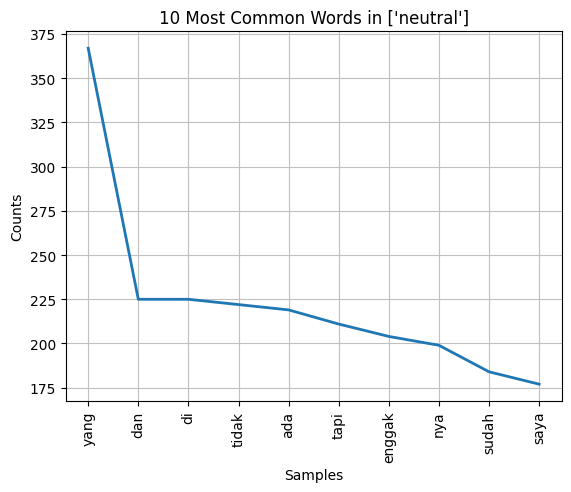

In [22]:
fqdist = nltk.probability.FreqDist(df1.clean_text)
print(fqdist.most_common(15))
fqdist.plot(10,cumulative=False)

# and what?
for i in df1.sentiment_label.unique():
    freqWords(df1, label=[i])

In [25]:
# save to df_clean
df1.to_csv("../data/df_clean.csv", index=False)